#  Review Summarization — Generative AI (OpenAI GPT)

**Upload these 2 files when prompted:**
- `Reviews_classified_Roberta_VADER.csv` — 5,195 reviews with RoBERTa sentiment labels
- `clustered_products.csv` — 48 products with cluster assignments

**Output files produced:**
- `generated_articles.json` — one article per cluster (for web app)
- `review_digest.html` — formatted HTML report (project deliverable)
- `sentiment_per_cluster.png` — chart for presentation

**Each article contains:**
- Top 3 products + what customers love
- Main complaint per product
- Comparison of top 3
- Worst product to avoid
- One-line verdict




## 📦 Step 1 — Install Dependencies

In [1]:
!pip install -q openai
print(' Done')

 Done


## 📂 Step 2 — Upload & Load Files

In [2]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import re
import time

# ── Upload both files when prompted ──────────────────────────────────
# 1. Reviews_classified_Roberta_VADER.csv
# 2. clustered_products.csv
print('Please upload both CSV files:')
print('  1. Reviews_classified_Roberta_VADER.csv')
print('  2. clustered_products.csv')
uploaded = files.upload()

Please upload both CSV files:
  1. Reviews_classified_Roberta_VADER.csv
  2. clustered_products.csv


Saving Reviews_classified_Roberta_VADER.csv to Reviews_classified_Roberta_VADER.csv
Saving clustered_products.csv to clustered_products.csv


In [3]:
# ── Load both files ───────────────────────────────────────────────────
df_reviews  = pd.read_csv('Reviews_classified_Roberta_VADER.csv', low_memory=False)
df_clusters = pd.read_csv('clustered_products.csv')

print('Reviews file  :', df_reviews.shape)
print('Clusters file :', df_clusters.shape)
print()
print('Cluster names found:')
print(df_clusters['cluster_name'].value_counts().to_string())

Reviews file  : (5195, 49)
Clusters file : (48, 4)

Cluster names found:
cluster_name
Mainstream Core Devices            19
Top-Rated & Premium Picks          18
Budget & Refurbished Essentials     6
Legacy & Niche Gadgets              3
Underperforming Outliers            2


In [4]:
# ── Merge: add cluster_name to every review row ───────────────────────
# clustered_products has: name, cluster_name, reviews.rating, categories
# df_reviews has: name, text, pred_label, rating, star_label, ...

df = df_reviews.merge(
    df_clusters[['name', 'cluster_name']],
    on='name',
    how='left'
)

# Reviews whose product wasn't clustered go to 'Other'
df['cluster_name'] = df['cluster_name'].fillna('Other')

# ── Use pred_label (RoBERTa predictions) as sentiment ─────────────────
# 0 = Negative, 1 = Neutral, 2 = Positive
df['sentiment'] = df['pred_label']

print(f'Merged shape : {df.shape}')
print(f'\nReviews per cluster:')
print(df['cluster_name'].value_counts().to_string())
print(f'\nSentiment distribution (pred_label):')
print(df['sentiment'].value_counts().rename({0:'Negative',1:'Neutral',2:'Positive'}).to_string())

Merged shape : (5195, 51)

Reviews per cluster:
cluster_name
Mainstream Core Devices            4078
Other                               999
Top-Rated & Premium Picks            76
Legacy & Niche Gadgets               39
Budget & Refurbished Essentials       3

Sentiment distribution (pred_label):
sentiment
Positive    4643
Neutral      406
Negative     146


##  Step 3 — Per-Product Stats & Charts

In [5]:
# ── Compute per-product stats within each cluster ─────────────────────
product_stats = (
    df[df['cluster_name'] != 'Other']
    .groupby(['cluster_name', 'name'])
    .agg(
        avg_rating   = ('rating',    'mean'),
        review_count = ('text',      'count'),
        positive_pct = ('sentiment', lambda x: (x == 2).mean()),
        negative_pct = ('sentiment', lambda x: (x == 0).mean()),
        neutral_pct  = ('sentiment', lambda x: (x == 1).mean()),
    )
    .reset_index()
)

# Only products with enough reviews
product_stats = product_stats[product_stats['review_count'] >= 3].copy()

# Composite score: avg_rating + positive_pct
product_stats['score'] = (
    product_stats['avg_rating'] * 0.5 +
    product_stats['positive_pct'] * 5 * 0.5
)

product_stats = product_stats.sort_values(
    ['cluster_name', 'score'], ascending=[True, False]
)

print(f'Products with ≥3 reviews: {len(product_stats)}')
product_stats[['cluster_name','name','avg_rating','review_count','positive_pct','negative_pct','score']].head(12)

Products with ≥3 reviews: 21


,cluster_name,name,avg_rating,review_count,positive_pct,negative_pct,score
3,Legacy & Niche Gadgets,"All-New Kindle E-reader - Black, 6 Glare-Free ...",4.358974,39,0.743590,0.102564,4.038462
20,Mainstream Core Devices,"Kindle Voyage E-reader, 6 High-Resolution Disp...",4.836957,92,0.956522,0.000000,4.809783
12,Mainstream Core Devices,Amazon Kindle Paperwhite - eBook reader - 4 GB...,4.753165,474,0.951477,0.008439,4.755274
9,Mainstream Core Devices,Amazon 9W PowerFast Official OEM USB Charger a...,4.500000,4,1.000000,0.000000,4.750000
8,Mainstream Core Devices,Amazon 5W USB Official OEM Charger and Power A...,4.793103,29,0.931034,0.000000,4.724138
14,Mainstream Core Devices,"Echo (White),,,\r\nEcho (White),,,",4.666667,468,0.918803,0.017094,4.630342
11,Mainstream Core Devices,"Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,",4.653951,367,0.912807,0.021798,4.608992
4,Mainstream Core Devices,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",4.573460,422,0.909953,0.026066,4.561611
10,Mainstream Core Devices,Amazon Fire Hd 8 8in Tablet 16gb Black B018szt...,4.750000,12,0.833333,0.000000,4.458333
13,Mainstream Core Devices,Brand New Amazon Kindle Fire 16gb 7 Ips Displa...,4.554913,173,0.867052,0.017341,4.445087


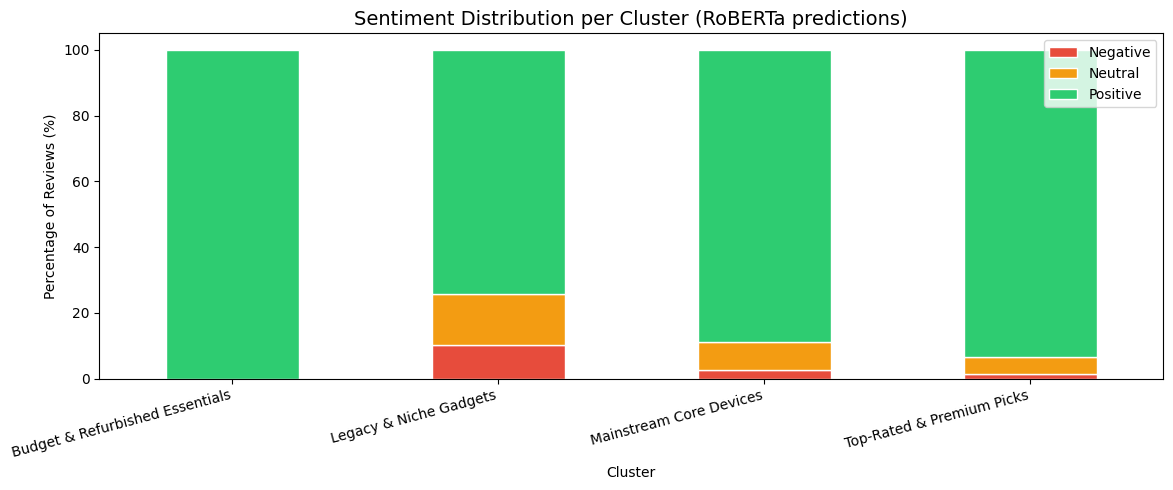

 Saved sentiment_per_cluster.png


In [6]:
# ── Sentiment distribution per cluster (for report/presentation) ──────
cluster_sentiment = (
    df[df['cluster_name'] != 'Other']
    .groupby(['cluster_name', 'sentiment'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: 'Negative', 1: 'Neutral', 2: 'Positive'})
)

# Ensure all columns exist
for col in ['Negative', 'Neutral', 'Positive']:
    if col not in cluster_sentiment.columns:
        cluster_sentiment[col] = 0
cluster_sentiment = cluster_sentiment[['Negative', 'Neutral', 'Positive']]

cluster_sentiment_pct = cluster_sentiment.div(
    cluster_sentiment.sum(axis=1), axis=0
) * 100

cluster_sentiment_pct.plot(
    kind='bar', stacked=True, figsize=(12, 5),
    color=['#e74c3c', '#f39c12', '#2ecc71'],
    edgecolor='white'
)
plt.title('Sentiment Distribution per Cluster (RoBERTa predictions)', fontsize=14)
plt.xlabel('Cluster')
plt.ylabel('Percentage of Reviews (%)')
plt.xticks(rotation=15, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('/content/sentiment_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved sentiment_per_cluster.png')

In [9]:
# ── Top 3 and worst product per cluster ───────────────────────────────
clusters = [c for c in df['cluster_name'].unique() if c != 'Other']

print('TOP 3 PRODUCTS PER CLUSTER')
print('=' * 75)
for cluster in clusters:
    subset = product_stats[product_stats['cluster_name'] == cluster]
    print(f'\n── {cluster} ──')
    print(f'  {"RANK":<5} {"Product":<52} {"Rating":>6}  {"+%":>5}  {"-%":>5}')
    print(f'  {"-"*5} {"-"*52} {"-"*6}  {"-"*5}  {"-"*5}')
    for rank, (_, row) in enumerate(subset.head(4).iterrows(), 1):
        marker = 'TOP' if rank <= 3 else 'BAD'
        print(f'  {marker:<5} {row["name"][:52]:<52} '
              f'{row["avg_rating"]:>6.2f}  '
              f'{row["positive_pct"]*100:>4.0f}%  '
              f'{row["negative_pct"]*100:>4.0f}%')
    if len(subset) > 3:
        row = subset.tail(1).iloc[0]
        print(f'  {"BAD":<5} {row["name"][:52]:<52} '
              f'{row["avg_rating"]:>6.2f}  '
              f'{row["positive_pct"]*100:>4.0f}%  '
              f'{row["negative_pct"]*100:>4.0f}%')

TOP 3 PRODUCTS PER CLUSTER

── Mainstream Core Devices ──
  RANK  Product                                              Rating     +%     -%
  ----- ---------------------------------------------------- ------  -----  -----
  TOP   Kindle Voyage E-reader, 6 High-Resolution Display (3   4.84    96%     0%
  TOP   Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 m   4.75    95%     1%
  TOP   Amazon 9W PowerFast Official OEM USB Charger and Pow   4.50   100%     0%
  BAD   Amazon 5W USB Official OEM Charger and Power Adapter   4.79    93%     0%
  BAD   Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Black,,,   4.25    50%     0%

── Legacy & Niche Gadgets ──
  RANK  Product                                              Rating     +%     -%
  ----- ---------------------------------------------------- ------  -----  -----
  TOP   All-New Kindle E-reader - Black, 6 Glare-Free Touchs   4.36    74%    10%

── Top-Rated & Premium Picks ──
  RANK  Product                                            

##  Step 4 — Prompt Builder

In [10]:
def get_cluster_candidates(cluster_name):
    """Return top 3 best and 1 worst product for a cluster."""
    cluster = product_stats[product_stats['cluster_name'] == cluster_name]
    top3    = cluster.head(3)['name'].tolist()
    worst   = cluster.tail(1)['name'].tolist()
    return top3, worst


def get_reviews_for_product(product_name, sentiment=None, n=8):
    """
    Fetch top n reviews for a product.
    sentiment: None=all, 0=Negative, 1=Neutral, 2=Positive
    Uses 'text' column (combined title+body) and 'sentiment' (pred_label).
    """
    subset = df[df['name'] == product_name].copy()
    if sentiment is not None:
        subset = subset[subset['sentiment'] == sentiment]
    # Longest reviews first — most informative
    subset = subset.sort_values(
        'text', key=lambda x: x.str.len(), ascending=False
    )
    reviews = subset['text'].head(n).astype(str).tolist()
    # Clean up messy text
    reviews = [r.replace('\r', ' ').replace('\n', ' ').strip() for r in reviews]
    return ' | '.join(reviews)


def build_prompt(cluster_name):
    """Build a structured GPT prompt using real review data."""
    top3, worst = get_cluster_candidates(cluster_name)

    if len(top3) == 0:
        return None

    sections = []
    for product in top3:
        pos   = get_reviews_for_product(product, sentiment=2, n=5)
        neg   = get_reviews_for_product(product, sentiment=0, n=3)
        stats = product_stats[product_stats['name'] == product]
        if stats.empty:
            continue
        s = stats.iloc[0]
        sections.append(
            f"PRODUCT: {product}\n"
            f"Avg Rating : {s['avg_rating']:.1f}/5  |  "
            f"Total Reviews: {int(s['review_count'])}  |  "
            f"{s['positive_pct']*100:.0f}% positive  "
            f"{s['negative_pct']*100:.0f}% negative\n"
            f"What customers love:\n{pos[:700]}\n"
            f"Main complaints:\n{neg[:350]}"
        )

    # Worst product
    worst_reviews = get_reviews_for_product(worst[0], sentiment=0, n=5)
    worst_stats   = product_stats[product_stats['name'] == worst[0]]
    worst_line    = ''
    if not worst_stats.empty:
        ws = worst_stats.iloc[0]
        worst_line = (
            f"Avg Rating: {ws['avg_rating']:.1f}/5  |  "
            f"{ws['negative_pct']*100:.0f}% negative  "
            f"({int(ws['review_count'])} reviews)"
        )

    product_block = '\n---\n'.join(sections)

    return f"""You are a professional tech journalist writing for a consumer review website.
Write a structured blog article for the product category: **{cluster_name}**

IMPORTANT: Use ONLY the review data provided below. Do not invent specs, prices, or opinions.

=== TOP PRODUCTS DATA ===
{product_block}

=== WORST PRODUCT DATA ===
PRODUCT: {worst[0]}
{worst_line}
Customer complaints:\n{worst_reviews[:550]}

=== ARTICLE STRUCTURE (follow exactly) ===
1. **Introduction** — 2 sentences introducing this product category
2. **Top 3 Products** — For each product:
   ### [Product Name]
   - 2-3 sentences on what customers consistently love
   - 1 sentence on the main complaint
3. **How They Compare** — 1 paragraph comparing the top 3 side by side
4. **Product to Avoid** — Name the worst product and explain why in 2-3 sentences
5. **Verdict** — 1 sentence recommendation for buyers

Tone: informative, neutral, consumer-friendly. Length: 350-450 words."""


# ── Preview prompt for first cluster ─────────────────────────────────
sample_prompt = build_prompt(clusters[0])
if sample_prompt:
    print(f' Prompt built for: {clusters[0]}')
    print('-' * 60)
    print(sample_prompt[:1000] + '...')
else:
    print(f'  Not enough data for {clusters[0]}')

 Prompt built for: Mainstream Core Devices
------------------------------------------------------------
You are a professional tech journalist writing for a consumer review website.
Write a structured blog article for the product category: **Mainstream Core Devices**

IMPORTANT: Use ONLY the review data provided below. Do not invent specs, prices, or opinions.

=== TOP PRODUCTS DATA ===
PRODUCT: Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Wi-Fi - Includes Special Offers,
Avg Rating : 4.8/5  |  Total Reviews: 92  |  96% positive  0% negative
What customers love:
Great reader.. Great for reading books. Print is easily readable. There are a couple of font sizes to adjust to your eyesight, as well as different font types to choose from. It's very easy to change them on the fly without going deep into settings.It has nice features, such as dictionary, where you can quickly check unfamiliar words while reading, create notes, or

##  Step 5 — OpenAI Setup


In [11]:
from openai import OpenAI
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')
client = OpenAI()

# ── Model choice ──────────────────────────────────────────────────────
# gpt-4o        → best quality,  ~$0.02  per article
# gpt-4o-mini   → great quality, ~$0.001 per article  ← recommended
# gpt-3.5-turbo → good quality,  ~$0.001 per article
OPENAI_MODEL = 'gpt-4o-mini'

print(f'✅ OpenAI ready — model: {OPENAI_MODEL}')
print(f'   Clusters to summarize: {len(clusters)}')
print(f'   Estimated cost: ~${len(clusters) * 0.002:.3f}')

✅ OpenAI ready — model: gpt-4o-mini
   Clusters to summarize: 4
   Estimated cost: ~$0.008


In [12]:
def generate_article(cluster_name):
    """Generate a recommendation article for the given cluster."""
    prompt = build_prompt(cluster_name)

    if prompt is None:
        return f'[Not enough product data for cluster: {cluster_name}]'

    response = client.chat.completions.create(
        model=OPENAI_MODEL,
        max_tokens=1024,
        temperature=0.7,
        messages=[
            {
                'role': 'system',
                'content': (
                    'You are a professional tech journalist writing clear, '
                    'neutral, well-structured product review articles for consumers. '
                    'Always follow the article structure provided exactly.'
                )
            },
            {
                'role': 'user',
                'content': prompt
            }
        ]
    )
    return response.choices[0].message.content


# ── Test with one cluster before generating all ───────────────────────
print(f'🧪 Test generation: {clusters[0]}\n')
print('-' * 60)
test_article = generate_article(clusters[0])
print(test_article)

🧪 Test generation: Mainstream Core Devices

------------------------------------------------------------
# Mainstream Core Devices: E-Readers for Every Book Lover

E-readers have transformed the way we consume literature, making it easier and more convenient to carry an entire library in our hands. In this article, we'll explore the top choices in the mainstream e-reader category, highlighting their strengths and weaknesses based on customer feedback.

## Top 3 Products

### Kindle Voyage E-reader
Customers rave about the Kindle Voyage for its high-resolution display (300 ppi) and adaptive built-in light, making reading comfortable in various lighting conditions. Users appreciate the ease of adjusting font sizes and types on-the-fly, as well as features like a built-in dictionary and note-taking capabilities. The straightforward process of downloading books via Wi-Fi is also a major plus. However, there are no notable complaints reported.

### Amazon Kindle Paperwhite
The Kindle Paperw

## 📝 Step 6 — Generate All Articles

In [13]:
articles = {}

for i, cluster in enumerate(clusters):
    print(f'\n[{i+1}/{len(clusters)}] 📝 {cluster}')
    print('-' * 55)
    try:
        article = generate_article(cluster)
        articles[cluster] = article
        print(article[:400] + '...')
    except Exception as e:
        print(f'  ⚠️  Failed: {e}')
        articles[cluster] = ''
    time.sleep(1)   # avoid rate limit

print('\n' + '=' * 55)
print(f' Generated {len([a for a in articles.values() if a])} / {len(clusters)} articles')


[1/4] 📝 Mainstream Core Devices
-------------------------------------------------------
# Mainstream Core Devices: Essential E-Readers for Every Book Lover

In the ever-evolving world of technology, e-readers have emerged as indispensable tools for avid readers. Offering the convenience of carrying an entire library in a compact form, these devices allow users to enjoy books without the distraction of notifications or eye strain common with tablets and smartphones.

## Top 3 Products...

[2/4] 📝 Legacy & Niche Gadgets
-------------------------------------------------------
# Legacy & Niche Gadgets: A Closer Look at E-Readers

In today’s digital age, legacy and niche gadgets continue to hold a special place in the hearts of consumers. Among these devices, e-readers stand out for their unique ability to provide a focused reading experience without the distractions of typical tablets or smartphones.

## Top 3 Products

### All-New Kindle E-reader - Black, 6 Glare-Free ...

[3/4] 📝 Top-Ra

##  Step 7 — Save Outputs

In [14]:
# ── Save as JSON ──────────────────────────────────────────────────────
with open('/content/generated_articles.json', 'w', encoding='utf-8') as f:
    json.dump(articles, f, indent=2, ensure_ascii=False)
print('Saved: /content/generated_articles.json')


# ── Markdown → HTML helper ────────────────────────────────────────────
def markdown_to_html(text):
    text = text.replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')
    text = re.sub(r'\*\*(.+?)\*\*', r'<strong>\1</strong>', text)
    text = re.sub(r'^### (.+)$', r'<h3>\1</h3>', text, flags=re.MULTILINE)
    text = re.sub(r'^## (.+)$',  r'<h2>\1</h2>', text, flags=re.MULTILINE)
    text = re.sub(r'^# (.+)$',   r'<h2>\1</h2>', text, flags=re.MULTILINE)
    text = re.sub(r'^[-*] (.+)$', r'<li>\1</li>', text, flags=re.MULTILINE)
    text = re.sub(r'(<li>.*?</li>\n?)+', lambda m: f'<ul>{m.group()}</ul>', text, flags=re.DOTALL)
    paragraphs = text.split('\n\n')
    out = []
    for p in paragraphs:
        p = p.strip()
        if p and not p.startswith('<h') and not p.startswith('<ul') and not p.startswith('<li'):
            p = f'<p>{p.replace(chr(10), " ")}</p>'
        out.append(p)
    return '\n'.join(out)


# ── Build HTML ────────────────────────────────────────────────────────
html = f'''<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Amazon Product Review Digest</title>
<style>
  body  {{ font-family: Georgia, serif; max-width: 860px; margin: 40px auto;
           line-height: 1.85; color: #1a1a1a; padding: 0 28px; }}
  h1    {{ color: #1a1a2e; border-bottom: 3px solid #4a6cf7;
           padding-bottom: 14px; font-size: 2em; }}
  .meta {{ color: #888; font-size: .9em; margin-bottom: 36px; }}
  .toc  {{ background: #f8f9ff; padding: 16px 24px;
           border: 1px solid #dde3ff; border-radius: 6px;
           margin-bottom: 48px; }}
  .toc a {{ color: #4a6cf7; text-decoration: none;
            display: block; padding: 4px 0; font-size: 1.05em; }}
  .toc a:hover {{ text-decoration: underline; }}
  .article-wrap {{ border-bottom: 1px solid #eee;
                   margin-bottom: 56px; padding-bottom: 32px; }}
  h2    {{ color: #1a1a2e; background: #f0f4ff; padding: 10px 18px;
           border-left: 5px solid #4a6cf7; margin-top: 0; font-size: 1.4em;
           border-radius: 0 4px 4px 0; }}
  h3    {{ color: #2c3e50; margin-top: 22px; font-size: 1.1em;
           border-bottom: 1px dashed #ccc; padding-bottom: 4px; }}
  p     {{ margin: 10px 0; }}
  ul    {{ margin: 8px 0 8px 24px; }}
  li    {{ margin: 5px 0; }}
  strong {{ color: #2c3e50; }}
</style>
</head>
<body>
<h1> Amazon Product Review Digest</h1>
<p class="meta">
  Auto-generated using NLP pipeline:<br>
  <strong>Sentiment</strong>: RoBERTa fine-tuned &nbsp;|&nbsp;
  <strong>Clustering</strong>: Sentence Transformers + KMeans &nbsp;|&nbsp;
  <strong>Summarization</strong>: OpenAI {OPENAI_MODEL}
</p>
<div class="toc">
<strong> Contents</strong><br><br>
'''

for cluster in articles:
    anchor = re.sub(r'[^a-z0-9-]', '', cluster.lower().replace(' ', '-').replace('&', 'and'))
    html += f'<a href="#{anchor}">▸ {cluster}</a>\n'

html += '</div>\n\n'

for cluster, article in articles.items():
    anchor       = re.sub(r'[^a-z0-9-]', '', cluster.lower().replace(' ', '-').replace('&', 'and'))
    article_html = markdown_to_html(article)
    html += f'<div class="article-wrap">\n'
    html += f'<h2 id="{anchor}">{cluster}</h2>\n'
    html += f'{article_html}\n'
    html += f'</div>\n\n'

html += '</body>\n</html>'

with open('/content/review_digest.html', 'w', encoding='utf-8') as f:
    f.write(html)

print(' Saved: /content/review_digest.html')
print('   Open in browser to read the full digest')

Saved: /content/generated_articles.json
 Saved: /content/review_digest.html
   Open in browser to read the full digest


##  Step 8 — Full Article Preview

In [15]:
for cluster, article in articles.items():
    print('\n' + '=' * 65)
    print(f'  CATEGORY: {cluster}')
    print('=' * 65)
    print(article)
    print()


  CATEGORY: Mainstream Core Devices
# Mainstream Core Devices: Essential E-Readers for Every Book Lover

In the ever-evolving world of technology, e-readers have emerged as indispensable tools for avid readers. Offering the convenience of carrying an entire library in a compact form, these devices allow users to enjoy books without the distraction of notifications or eye strain common with tablets and smartphones.

## Top 3 Products

### Kindle Voyage E-reader
Customers appreciate the Kindle Voyage for its high-resolution 300 ppi display and adaptive built-in light, which makes reading comfortable in various lighting conditions. The PagePress sensors allow for seamless page turning, and the device supports multiple font types and sizes for personalized reading experiences. The only noted concern is that some users wish for more options when it comes to adjusting settings quickly.

### Amazon Kindle Paperwhite
The Kindle Paperwhite is lauded for its lightweight design and ease of use, 

##  Step 9 — Download All Output Files

In [16]:
from google.colab import files

print('Downloading 3 files...')
files.download('/content/generated_articles.json')
files.download('/content/review_digest.html')
files.download('/content/sentiment_per_cluster.png')
print(' Check your browser downloads folder')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Check your browser downloads folder


##  Step 10 — Final Summary Report

In [17]:
print('=' * 65)
print('  SUMMARIZATION RESULTS')
print('=' * 65)
print(f'  Model             : {OPENAI_MODEL}')
print(f'  Input reviews     : {len(df)} total ({len(df[df["cluster_name"] != "Other"])} clustered)')
print(f'  Clusters covered  : {len([a for a in articles.values() if a])} / {len(clusters)}')
print()
print(f'  {"Cluster":<40}  {"Words":>6}  Status')
print(f'  {"-"*40}  {"-"*6}  ------')
for cluster, article in articles.items():
    words  = len(article.split()) if article else 0
    status = 'Success' if words > 100 else 'Short' if words > 0 else 'Failed'
    print(f'  {cluster:<40}  {words:>6}  {status}')
print()
print('  Output files:')
print('  /content/generated_articles.json    → for Gradio / web app')
print('  /content/review_digest.html          → project deliverable')
print('  /content/sentiment_per_cluster.png   → for presentation')
print('=' * 65)

  SUMMARIZATION RESULTS
  Model             : gpt-4o-mini
  Input reviews     : 5195 total (4196 clustered)
  Clusters covered  : 4 / 4

  Cluster                                    Words  Status
  ----------------------------------------  ------  ------
  Mainstream Core Devices                      427  Success
  Legacy & Niche Gadgets                       325  Success
  Top-Rated & Premium Picks                    426  Success
  Budget & Refurbished Essentials               10  Short

  Output files:
  /content/generated_articles.json    → for Gradio / web app
  /content/review_digest.html          → project deliverable
  /content/sentiment_per_cluster.png   → for presentation
